## Task 1 - Insertion Sort

The following cell implements the **insertion sort algorithm** 

- **Input:** A list of unsorted numbers
- **Output:** A sorted copy of the input list

The algorithm is then tested on a random list generated with `random.sample(range(1, 200), 10)`.

In [ ]:
import random

def insertion_sort(array):
    # Make a copy of the original array for sorting
    sorted_array = array.copy()
    n = len(sorted_array)
    
    for i in range(1, n):
        key = sorted_array[i]
        j = i-1

        while j >=0 and sorted_array[j] > key:
            sorted_array[j+1] = sorted_array[j]
            j -= 1

            sorted_array[j+1] = key
    return sorted_array
    

In [9]:
lorig = random.sample(range(1,200), 10)
lsorted = insertion_sort(lorig)
lorig.sort()

print("insertion sort works:", lorig == lsorted)

insertion sort works: True


## Task 2 - Shellsort

In this task, I implemented the **Shellsort algorithm**, which optimises insertion sort by allowing exchanges of elements that are far apart. The main idea is to initially compare elements seperated by a large `gap`, progressively reducing the gap until it becomes 1, at which point the list is fully sorted.

For each `gap`, the list is devided into several sub lists, each of which is sorted independently using `insertion_sort()` from Task 1. This ensures elements far apart are moved closer to their correct positions early, reducing the amount of shifting needed later on.

Two common gap sequences are included:

- **Halving gaps:** repeatedly divide by 2
- **Knuth gaps:** follow the iterative rule `3k + 1`

In [17]:
def halving_gaps(n):
    gaps = []
    gap = n/2
    while gap >= 1:
        gaps.append(int(gap))
        gap /= 2
    return gaps

def Knuth_gaps(n):
    gaps = [1]
    while 3*gaps[-1] + 1 <n:
        gaps.append(3*gaps[-1] + 1)
    return gaps[::-1]

def shell_sort(array, gaps = None):

    sorted_array = array.copy()
    n = len(sorted_array)

    if gaps is None:
        gap_list = halving_gaps(n)
    elif callable(gaps):
        gap_list = gaps(n)
    elif isinstance(gaps, list):
        gap_list = gaps
    else:
        raise ValueError("gaps must be None, a callable function, or a list of integers")
    
    # Ensure user provided gaps are valid
    # And the gaps go from largest to smallest
    # ending with a regular insertion sort
    gap_list  = [int(g) for g in gap_list if 1 <= int(g) < n]
    if 1 not in gap_list:
        gap_list.append(1)
    gap_list = sorted(set(gap_list), reverse=True)

    for gap in gap_list:
        for start in range (gap):
            slice_idx = list(range(start, n, gap))
            slice_vals = [sorted_array[idx] for idx in slice_idx]
            sorted_slice = insertion_sort(slice_vals)
            for k , v in zip(slice_idx, sorted_slice):
                sorted_array[k] = v
    return sorted_array

### Example test

In [18]:
arr = random.sample(range(1, 200), 10)
print("Original:", arr)

# Default (halving sequence)
print("Halving gaps:", shell_sort(arr, gaps=halving_gaps))

# Custom gaps (e.g. Knuth sequence)
print("Knuth gaps:", shell_sort(arr, gaps=Knuth_gaps))

# Another custom sequence
print("Custom gaps [5, 2, 1]:", shell_sort(arr, gaps=[5, 2, 1]))

Original: [39, 115, 155, 78, 109, 29, 132, 24, 19, 146]
Halving gaps: [19, 24, 29, 39, 78, 109, 115, 132, 146, 155]
Knuth gaps: [19, 24, 29, 39, 78, 109, 115, 132, 146, 155]
Custom gaps [5, 2, 1]: [19, 24, 29, 39, 78, 109, 115, 132, 146, 155]


## Task 3 - Runtime

The cell below measures the runtime of `insertion_sort()` and `shell_sort()` on random integer lists, as well as python's built-in `list.sort()`.

Two different gap sequences (halving and Knuth) were used for comparing behaviour.

**Note:**

The runtime measurements were performed for array sizesup to $2^{15}$ (rather than $2^{20}$) using `sizes = [2**k for k in range(5,16)]`.

This limitation was chosen because **insertion sort** becomes extremely slow for large arrays, making it impractical to benchmark within a reasonable runtime.

The tested range is still sufficient to clearly observe the scaling behaviour of all algorithms.



In [ ]:
import time, json, csv, random
from statistics import mean, stdev
from pathlib import Path

# Helper functions for benchmarking

def timer(func, data):
    t0 = time.perf_counter()
    _ = func(data)
    return time.perf_counter() - t0

def bench(name, func, n, repeats=10, seed0=123):
    times = []
    domain = range(1, max(10*n, 2000))
    for r in range(repeats):
        random.seed(seed0 + r)
        arr = random.sample(domain, n)
        times.append(timer(func, arr))
    return {
        "algo": name,
        "n": n,
        "mean": mean(times),
        "stdev": stdev(times) if repeats > 1 else 0.0
    }

# Sizes to test
sizes = [2**k for k in range(5,16)]

# Include more repeats for smaller n to reduce noise
results = []
Small_n = 2**12
repeats_small = 12
repeats_large = 6

for n in sizes:
    reps = repeats_small if n <= Small_n else repeats_large

    # Insertion sort
    results.append(bench("Insertion Sort", insertion_sort, n, repeats=reps))

    # Shellsort with halving gaps
    results.append(bench("Shell_halving",
                    lambda a, n=n: shell_sort(a, gaps=halving_gaps),
                     n, repeats=reps))
    
    # Shellsort with Knuth gaps
    results.append(bench("shell_knuth",
                         lambda a, n=n: shell_sort(a, gaps=Knuth_gaps),
                         n, repeats=reps))
    
    # Pythons built in sort
    results.append(bench("Python_sort", lambda a: sorted(a), n, repeats=reps))

# Save results to CSV and JSON
out_dir = Path(".")
csv_path = out_dir / "runtime_results.csv"
json_path = out_dir / "runtime_results.json"

with csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["algo", "n", "mean", "stdev"])
    writer.writeheader()
    writer.writerows(results)

with json_path.open("w") as f:
    json.dump(results, f, indent=2)

print(f"Saved {len(results)} benchmark results to {csv_path} and {json_path}")

for row in results[:8]:
    print(row)

Saved 44 benchmark results to runtime_results.csv and runtime_results.json
{'algo': 'Insertion Sort', 'n': 32, 'mean': 3.055558408959769e-05, 'stdev': 4.5032617596482864e-06}
{'algo': 'Shell_halving', 'n': 32, 'mean': 8.516674976514575e-05, 'stdev': 4.1365011318688785e-05}
{'algo': 'shell_knuth', 'n': 32, 'mean': 6.131600002845516e-05, 'stdev': 3.5937834594823696e-05}
{'algo': 'Python_sort', 'n': 32, 'mean': 1.6666660182333242e-06, 'stdev': 2.1754516930755783e-07}
{'algo': 'Insertion Sort', 'n': 64, 'mean': 9.789933271046418e-05, 'stdev': 7.030547756691149e-06}
{'algo': 'Shell_halving', 'n': 64, 'mean': 0.00011881591702452472, 'stdev': 8.102226720502423e-06}
{'algo': 'shell_knuth', 'n': 64, 'mean': 9.188891696491434e-05, 'stdev': 6.183973813943574e-06}
{'algo': 'Python_sort', 'n': 64, 'mean': 3.33325078827329e-06, 'stdev': 3.501764411376188e-07}


## Task 4 - Empirical analysis of computational complexity

The plot below compares the **runtime scaling** of different sorting algorithms over increasing array sizes (on log-log axes). Data was obtained by averaging multiple runs for each `n` to reduce timing noise.

**Observations:**
- **Insertion sort** shows a steep slope consistent with **𝑂(n²)** growth, performing well only for small arrays.
- **ShellSort** (both halving and Knuth gap sequences) achieves a much slower growth rate, closer to **𝑂($n^{\frac{3}{2}}$)**, confirming its improved efficiency.
- The **Knuth gap** version consistently outperforms the simple halving sequence for large `n`.
- Python's built-in `list.sort()` is the fastest, scaling roughly as **O(n log n)** and serving as a baseline.

Overall, the empirical trends match the theoretical expectations:

Insertion Sort >> ShellSort >> Python Sort in terms of runtime as `n` increases.

Algorithms found: ['Insertion Sort' 'Shell_halving' 'shell_knuth' 'Python_sort']


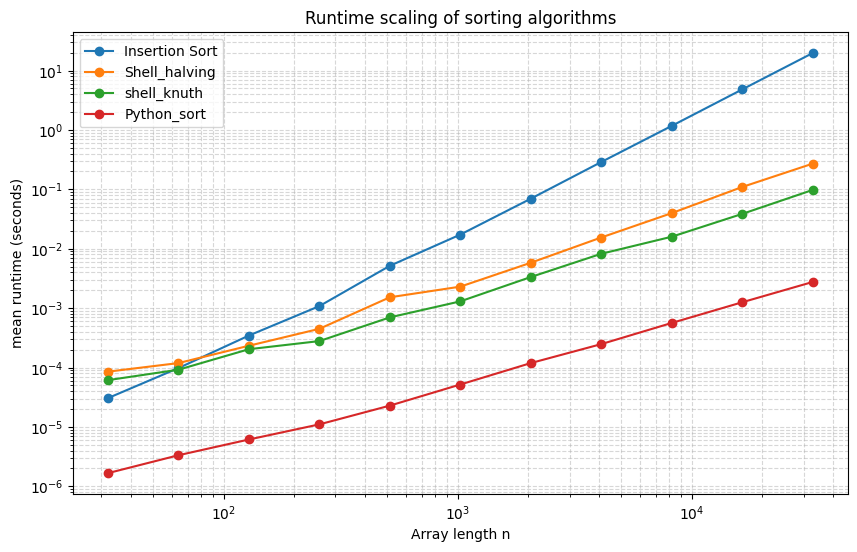

In [22]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load benchmark results
csv_path = Path("runtime_results.csv")
df = pd.read_csv(csv_path)

# Organise the data
algorithms = df['algo'].unique()
print ("Algorithms found:", algorithms)

# Plot runtime vs n on log-log axes
plt.figure(figsize=(10, 6))
for algo in algorithms:
    data = df[df['algo'] == algo].sort_values("n")
    plt.loglog(data["n"], data["mean"], "o-", label=algo)


plt.xlabel("Array length n")
plt.ylabel("mean runtime (seconds)")
plt.title("Runtime scaling of sorting algorithms")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

## Task 5 – Some maths on Big O 

Using Taylor series expansions about \(h = 0\):

| Function | Expansion | Leading term | Big-O | \(p\) |
|-----------|------------|---------------|--------|------|
| $\sin(h)$ | $$\sin(h) = h - \frac{h^3}{6} + \dots$$ | $$h$$ | $$O(h)$$ | **1** |
| $\cos(h) - 1$ | $$\cos(h) - 1 = -\frac{h^2}{2} + \frac{h^4}{24} + \dots$$ | $$h^2$$ | $$O(h^2)$$ | **2** |
| $\exp(h) - h$ | $$\exp(h) - h = 1 + \frac{h^2}{2} + \frac{h^3}{3} + \dots$$ | $$h^2$$ | $$1 + O(h^2)$$ | **2** |

These results confirm that the dominant power of \(h\) — the smallest exponent with a non-zero coefficient — determines the order of magnitude in the $O(h^p)$ notation.

## Task 6 – Some maths on DEs 

We are given:

$$
y_{k+2} - 3y_{k+1} - 4y_k = f(k), \quad y_0 = 3, \; y_1 = 2
$$


#### (1) Order
The largest forward shift is $k+2$, so the equation is **second order**.



#### (2) Homogeneous case 

Characteristic equation:

$$
r^2 - 3r - 4 = 0 \Rightarrow r_1 = 4, \; r_2 = -1
$$

$$
\boxed{ y_k^{(h)} = A \cdot 4^k + B \cdot (-1)^k}
$$



#### (3) Non-homogeneous case $f(k)=5$

Try a constant $y_k^{(p)} = C$:

$$
C - 3C - 4C = 5 \Rightarrow C = -\frac{5}{6}
$$

Hence

$$
y_k = A \cdot 4^k + B \cdot (-1)^k - \frac{5}{6}
$$

Using $y_0 = 3, \; y_1 = 2$:

$$
\begin{cases}
A + B = \tfrac{23}{6} \\
4A - B = \tfrac{17}{6}
\end{cases}
\Rightarrow
A = \tfrac{4}{3}, \; B = \tfrac{5}{2}
$$

---

**Final solution:**

$$
\boxed{y_k = \frac{4}{3} \cdot 4^k + \frac{5}{2} \cdot (-1)^k - \frac{5}{6}}
$$